<a href="https://colab.research.google.com/github/gaeun1018/CV_Study/blob/main/cassava/seoneun/week2/EDA%20%26%20baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 데이터 로드

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

if not os.path.exists("/content/1000015157.jpg"):
    print("압축 푸는 중...")
    !unzip -q "/content/drive/MyDrive/kaggle_study/train_images.zip" -d "/content/"
else:
    print("이미 압축 풀려 있음")

압축 푸는 중...


In [4]:
CSV_PATH = "/content/drive/MyDrive/kaggle_study/train.csv"
IMG_PATH = "/content"

In [5]:
import pandas as pd

df = pd.read_csv(CSV_PATH)
df.head()

,image_id,label
0,1000015157.jpg,0
1,1000201771.jpg,3
2,100042118.jpg,1
3,1000723321.jpg,1
4,1000812911.jpg,3


# EDA

| label | 의미                        |
| ----- | ------------------------- |
| 0     | Cassava Bacterial Blight  |
| 1     | Brown Streak Disease      |
| 2     | Green Mottle              |
| 3     | Mosaic Disease  |
| 4     | Healthy                   |


In [6]:
print("데이터 개수:", len(df))
print(df.columns)

데이터 개수: 21397
Index(['image_id', 'label'], dtype='object')


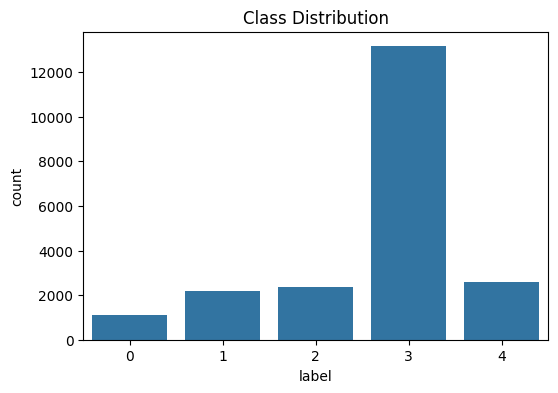

,count
label,
3,13158
4,2577
2,2386
1,2189
0,1087


In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

df['label'].value_counts()

/content/1000015157.jpg
True
이미지 크기: (800, 600)


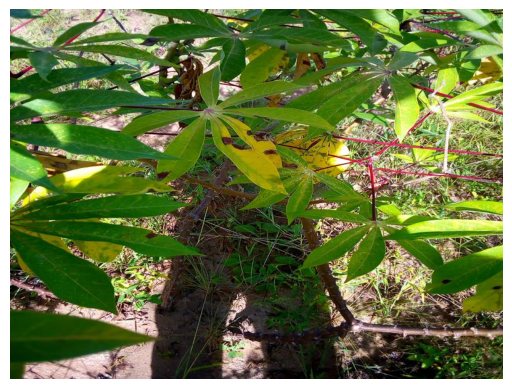

In [8]:
import os
from PIL import Image

img_path = os.path.join(IMG_PATH, df.iloc[0]['image_id'])

print(img_path)
print(os.path.exists(img_path))

img = Image.open(img_path)

plt.imshow(img)
plt.axis('off')
print("이미지 크기:", img.size)

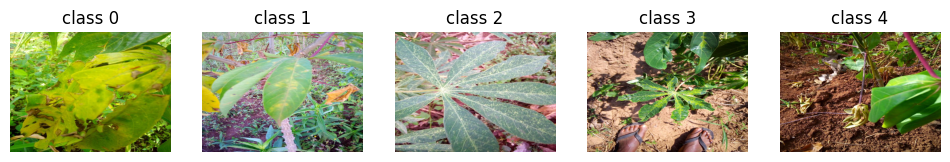

In [9]:
plt.figure(figsize=(12,5))

for label in range(5):
    sample = df[df['label'] == label].sample(1)
    img_path = os.path.join(IMG_PATH, sample.iloc[0]['image_id'])

    img = Image.open(img_path)

    plt.subplot(1,5,label+1)
    plt.imshow(img)
    plt.title(f"class {label}")
    plt.axis('off')

plt.show()

In [10]:
sizes = []

for i in range(300):
    img_path = os.path.join(IMG_PATH, df.iloc[i]['image_id'])
    img = Image.open(img_path)
    sizes.append(img.size)

widths = [s[0] for s in sizes]
heights = [s[1] for s in sizes]

print("width 평균:", sum(widths)/len(widths))
print("height 평균:", sum(heights)/len(heights))

width 평균: 800.0
height 평균: 600.0


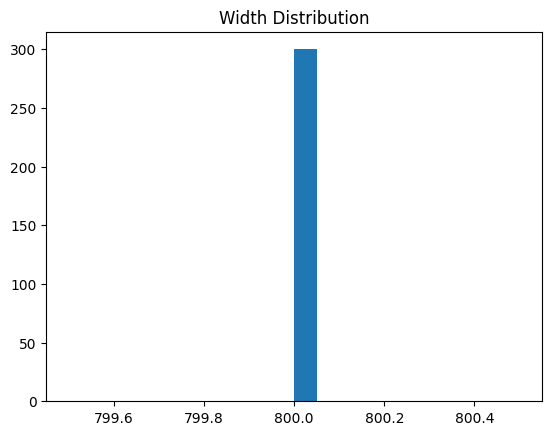

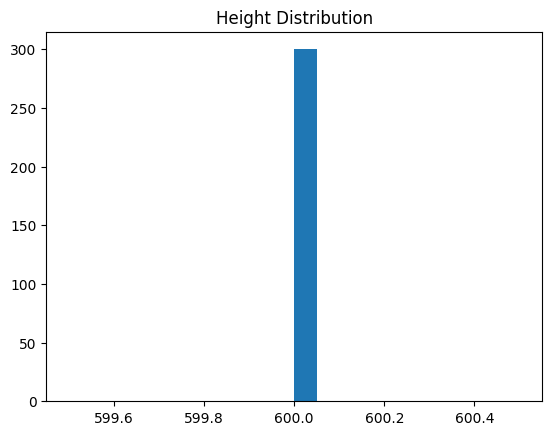

In [11]:
plt.hist(widths, bins=20)
plt.title("Width Distribution")
plt.show()

plt.hist(heights, bins=20)
plt.title("Height Distribution")
plt.show()

# baseline

In [12]:
from sklearn.model_selection import train_test_split

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['label'],  # 🔥 중요
    random_state=42
)

In [13]:
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2),
    transforms.ToTensor()
])

val_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [14]:
from torch.utils.data import Dataset

class CassavaDataset(Dataset):
    def __init__(self, df, img_path, transform=None):
        self.df = df
        self.img_path = img_path
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        img_name = self.df.iloc[idx]['image_id']
        label = self.df.iloc[idx]['label']

        img = Image.open(os.path.join(self.img_path, img_name)).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, label

In [15]:
import torchvision.models as models
import torch.nn as nn

model = models.efficientnet_b0(pretrained=True)

model.classifier[1] = nn.Linear(model.classifier[1].in_features, 5)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 150MB/s]


In [16]:
import torch
from torch.utils.data import DataLoader

train_dataset = CassavaDataset(train_df, IMG_PATH, transform=train_transform)
val_dataset = CassavaDataset(val_df, IMG_PATH, transform=val_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("train batches:", len(train_loader))
print("val batches:", len(val_loader))

train batches: 535
val batches: 134


In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

model = model.to(device)

cuda


In [18]:
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [19]:
def calculate_accuracy(outputs, labels):
    preds = outputs.argmax(dim=1)
    correct = (preds == labels).sum().item()
    return correct / len(labels)

In [20]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    running_acc = 0.0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        acc = calculate_accuracy(outputs, labels)

        running_loss += loss.item()
        running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [21]:
def validate(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    running_acc = 0.0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            acc = calculate_accuracy(outputs, labels)

            running_loss += loss.item()
            running_acc += acc

    epoch_loss = running_loss / len(loader)
    epoch_acc = running_acc / len(loader)

    return epoch_loss, epoch_acc

In [22]:
num_epochs = 5

for epoch in range(num_epochs):
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-" * 40)

Epoch [1/5]
Train Loss: 0.6361 | Train Acc: 0.7771
Val   Loss: 0.6552 | Val   Acc: 0.7679
----------------------------------------
Epoch [2/5]
Train Loss: 0.5006 | Train Acc: 0.8221
Val   Loss: 0.5121 | Val   Acc: 0.8285
----------------------------------------
Epoch [3/5]
Train Loss: 0.4535 | Train Acc: 0.8431
Val   Loss: 0.4575 | Val   Acc: 0.8369
----------------------------------------
Epoch [4/5]
Train Loss: 0.4364 | Train Acc: 0.8483
Val   Loss: 0.4937 | Val   Acc: 0.8291
----------------------------------------
Epoch [5/5]
Train Loss: 0.4069 | Train Acc: 0.8563
Val   Loss: 0.4375 | Val   Acc: 0.8526
----------------------------------------
